In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# PyTorch 2.3.1 + CUDA 12.1 — has pre-built mamba_ssm wheels
!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu121 -q

In [2]:
!pip install torchvision==0.18.1 -q
!pip install transformers==4.40.0 -q
!pip install tokenizers==0.19.1 -q
!pip install torchmetrics==1.4.0 -q
!pip install medpy -q
!pip install timm einops albumentations -q

In [3]:
import torch
print(torch.version.cuda)
print(torch.__version__)

12.1
2.3.1+cu121


In [4]:
!pip install causal-conv1d==1.4.0 -q
!pip install mamba-ssm==2.2.2 -q

In [5]:
import torch
from mamba_ssm.ops.selective_scan_interface import selective_scan_fn
print("mamba_ssm loaded successfully!")
print(torch.__version__)   # should be 2.3.1+cu121

mamba_ssm loaded successfully!
2.3.1+cu121


In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torchmetrics
from torchmetrics import JaccardIndex, F1Score, Accuracy, Precision, Recall, Specificity
from medpy.metric import binary

# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [9]:
!sed -i 's/from .vmamba import/from vmamba import/' /content/vmunet.py

In [10]:
!head -3 /content/vmunet.py  # should show: from vmamba import VSSM

from vmamba import VSSM
import torch
from torch import nn


In [16]:
vmunet_code = '''from vmamba import VSSM
import torch
from torch import nn


class VMUNet(nn.Module):
    def __init__(self,
                 input_channels=3,
                 num_classes=1,
                 depths=[2, 2, 9, 2],
                 depths_decoder=[2, 9, 2, 2],
                 drop_path_rate=0.2,
                 load_ckpt_path=None,
                ):
        super().__init__()
        self.load_ckpt_path = load_ckpt_path
        self.num_classes = num_classes
        self.vmunet = VSSM(in_chans=input_channels,
                           num_classes=num_classes,
                           depths=depths,
                           depths_decoder=depths_decoder,
                           drop_path_rate=drop_path_rate,
                        )

    def forward(self, x):
        if x.size()[1] == 1:
            x = x.repeat(1,3,1,1)
        logits = self.vmunet(x)
        if self.num_classes == 1: return torch.sigmoid(logits)
        else: return logits

    def load_from(self):
        if self.load_ckpt_path is not None:
            model_dict = self.vmunet.state_dict()
            modelCheckpoint = torch.load(self.load_ckpt_path)
            pretrained_dict = modelCheckpoint["model"]
            new_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict.keys()}
            model_dict.update(new_dict)
            print("Total model_dict: {}, Total pretrained_dict: {}, update: {}".format(len(model_dict), len(pretrained_dict), len(new_dict)))
            self.vmunet.load_state_dict(model_dict)
            not_loaded_keys = [k for k in pretrained_dict.keys() if k not in new_dict.keys()]
            print("Not loaded keys:", not_loaded_keys)
            print("encoder loaded finished!")

            model_dict = self.vmunet.state_dict()
            modelCheckpoint = torch.load(self.load_ckpt_path)
            pretrained_odict = modelCheckpoint["model"]
            pretrained_dict = {}
            for k, v in pretrained_odict.items():
                if "layers.0" in k:
                    pretrained_dict[k.replace("layers.0", "layers_up.3")] = v
                elif "layers.1" in k:
                    pretrained_dict[k.replace("layers.1", "layers_up.2")] = v
                elif "layers.2" in k:
                    pretrained_dict[k.replace("layers.2", "layers_up.1")] = v
                elif "layers.3" in k:
                    pretrained_dict[k.replace("layers.3", "layers_up.0")] = v
            new_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict.keys()}
            model_dict.update(new_dict)
            print("Total model_dict: {}, Total pretrained_dict: {}, update: {}".format(len(model_dict), len(pretrained_dict), len(new_dict)))
            self.vmunet.load_state_dict(model_dict)
            not_loaded_keys = [k for k in pretrained_dict.keys() if k not in new_dict.keys()]
            print("Not loaded keys:", not_loaded_keys)
            print("decoder loaded finished!")
'''

with open('/content/vmunet.py', 'w') as f:
    f.write(vmunet_code)

print("vmunet.py written successfully!")
!head -2 /content/vmunet.py  # should show: from vmamba import VSSM

vmunet.py written successfully!
from vmamba import VSSM
import torch


In [17]:
from vmunet import VMUNet
print("VMUNet imported successfully!")

VMUNet imported successfully!


In [18]:
from google.colab import drive
import shutil
import os
import shutil, os
drive_source = '/content/drive/MyDrive/VMUNet_files/'
for file in ['vmamba.py', 'vmunet.py']:
    src = os.path.join(drive_source, file)
    if os.path.exists(src):
        shutil.copy(src, '.')
        print(f"✅ {file} loaded")
    else:
        print(f"❌ Missing: {file}")

# Now you can import
from vmunet import VMUNet
print("VMUNet imported successfully!")

✅ vmamba.py loaded
✅ vmunet.py loaded
VMUNet imported successfully!


In [10]:
for file in ['vmamba.py', 'vmunet.py']:
    src = os.path.join(drive_source, file)
    if os.path.exists(src):
        shutil.copy(src, '.')
        print(f"✅ {file} loaded")
    else:
        print(f"❌ Missing: {file}")

# Fix the import in vmunet.py
with open('vmunet.py', 'r') as f:
    content = f.read()

# Replace relative import with absolute import
content = content.replace('from .vmamba import VSSM', 'from vmamba import VSSM')

with open('vmunet.py', 'w') as f:
    f.write(content)

print("Fixed vmunet.py: changed relative import to absolute import")

# Now import
from vmunet import VMUNet
print("VMUNet imported successfully!")

✅ vmamba.py loaded
✅ vmunet.py loaded
Fixed vmunet.py: changed relative import to absolute import
VMUNet imported successfully!


In [19]:
data_dir = "/content/drive/MyDrive/Kvasir-SEG"
image_dir = os.path.join(data_dir, "images")
mask_dir = os.path.join(data_dir, "masks")

IMG_HEIGHT = 256
IMG_WIDTH = 256
batch_size = 8          # adjust based on GPU memory
learning_rate = 1e-3
num_epochs = 100
patience = 40

os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Get all image and mask files
image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))
image_paths = [os.path.join(image_dir, f) for f in image_files]
mask_paths = [os.path.join(mask_dir, f) for f in mask_files]

# Split
from sklearn.model_selection import train_test_split
temp = list(zip(image_paths, mask_paths))
train_val, test = train_test_split(temp, test_size=0.15, random_state=42)
train, val = train_test_split(train_val, test_size=0.15/0.85, random_state=42)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 700, Val: 150, Test: 150


In [20]:
class KvasirDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = torch.from_numpy(image).permute(2,0,1).float() / 255.0
            mask = torch.from_numpy(mask).long()
        return image, mask

# Transforms
train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_dataset = KvasirDataset(*zip(*train), transform=train_transform)
val_dataset = KvasirDataset(*zip(*val), transform=val_transform)
test_dataset = KvasirDataset(*zip(*test), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [21]:
class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.bce = nn.BCELoss()   # now expects probabilities

    def forward(self, inputs, targets):
        # inputs: (N,1,H,W) probabilities in [0,1]
        # targets: (N,H,W) long (0/1)
        inputs = inputs.squeeze(1)  # (N,H,W)
        targets = targets.float()

        smooth = 1e-5
        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)

        bce_loss = self.bce(inputs, targets)

        return self.dice_weight * dice_loss + self.bce_weight * bce_loss

criterion = DiceBCELoss().to(device)

In [22]:
from vmunet import VMUNet

model = VMUNet(
    input_channels=3,
    num_classes=1,
    depths=[2, 2, 9, 2],
    depths_decoder=[2, 9, 2, 2],
    drop_path_rate=0.2,
    load_ckpt_path=None   # optionally set to pre-trained checkpoint path
).to(device)

# Optional: load pre-trained encoder weights (comment out if not needed)
# model.load_from()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

print(f"Total parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

Total parameters: 44.27M


In [23]:
jaccard = JaccardIndex(task='binary').to(device)
dice = F1Score(task='binary').to(device)
accuracy = Accuracy(task='binary').to(device)
precision = Precision(task='binary').to(device)
recall = Recall(task='binary').to(device)
specificity = Specificity(task='binary').to(device)

def compute_hausdorff(pred_mask, true_mask, spacing=(1,1)):
    pred_binary = pred_mask.astype(np.uint8)
    true_binary = true_mask.astype(np.uint8)
    if np.sum(pred_binary) == 0 or np.sum(true_binary) == 0:
        return np.nan, np.nan
    hd = binary.hd(pred_binary, true_binary, voxelspacing=spacing)
    hd95 = binary.hd95(pred_binary, true_binary, voxelspacing=spacing)
    return hd, hd95

In [24]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total_pixels = 0

    for images, masks in tqdm(dataloader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)          # (N,1,H,W) probabilities
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = (outputs > 0.5).squeeze(1).long()
        correct += (preds == masks).sum().item()
        total_pixels += masks.numel()

    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total_pixels
    return avg_loss, avg_acc

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    jaccard.reset()
    dice.reset()
    accuracy.reset()
    precision.reset()
    recall.reset()
    specificity.reset()
    hd_list, hd95_list = [], []

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Validation'):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            preds = (outputs > 0.5).squeeze(1).long()

            jaccard.update(preds, masks)
            dice.update(preds, masks)
            accuracy.update(preds, masks)
            precision.update(preds, masks)
            recall.update(preds, masks)
            specificity.update(preds, masks)

            for i in range(images.size(0)):
                pred_np = preds[i].cpu().numpy()
                mask_np = masks[i].cpu().numpy()
                hd, hd95 = compute_hausdorff(pred_np, mask_np)
                hd_list.append(hd)
                hd95_list.append(hd95)

    avg_loss = total_loss / len(dataloader)
    metrics = {
        'loss': avg_loss,
        'val_accuracy': accuracy.compute().cpu().item(),
        'jaccard': jaccard.compute().cpu().item(),
        'dice': dice.compute().cpu().item(),
        'precision': precision.compute().cpu().item(),
        'recall': recall.compute().cpu().item(),
        'specificity': specificity.compute().cpu().item(),
        'hd_mean': np.nanmean(hd_list),
        'hd95_mean': np.nanmean(hd95_list)
    }
    return metrics

In [26]:
log_file = "logs/training_log.csv"
csv_columns = ['epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy',
               'jaccard', 'dice', 'precision', 'recall', 'specificity',
               'hd_mean', 'hd95_mean']

if not os.path.exists(log_file):
    pd.DataFrame(columns=csv_columns).to_csv(log_file, index=False)

best_val_loss = float('inf')
patience_counter = 0
history = defaultdict(list)

for epoch in range(1, num_epochs+1):
    print(f"\nEpoch {epoch}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_metrics['loss'])

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_acc)
    history['val_loss'].append(val_metrics['loss'])          # ← key fix
    history['val_accuracy'].append(val_metrics['val_accuracy'])
    history['jaccard'].append(val_metrics['jaccard'])
    history['dice'].append(val_metrics['dice'])
    history['precision'].append(val_metrics['precision'])
    history['recall'].append(val_metrics['recall'])
    history['specificity'].append(val_metrics['specificity'])
    history['hd_mean'].append(val_metrics['hd_mean'])
    history['hd95_mean'].append(val_metrics['hd95_mean'])

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    print(f"Train Acc:  {train_acc:.4f} | Val Acc:  {val_metrics['val_accuracy']:.4f}")
    print(f"Jaccard: {val_metrics['jaccard']:.4f} | Dice: {val_metrics['dice']:.4f}")
    print(f"HD: {val_metrics['hd_mean']:.2f} | HD95: {val_metrics['hd95_mean']:.2f}")

    row = {col: history[col][-1] for col in csv_columns}
    pd.DataFrame([row]).to_csv(log_file, mode='a', header=False, index=False)

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save(model.state_dict(), 'models/best_vmunet.pth')
        print("Best model saved!")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

torch.save(model.state_dict(), 'models/final_vmunet.pth')


Epoch 1/100


Validation: 100%|██████████| 19/19 [00:09<00:00,  2.09it/s]


Train Loss: 0.5464 | Val Loss: 0.5433
Train Acc:  0.8112 | Val Acc:  0.7942
Jaccard: 0.2230 | Dice: 0.3647
HD: 109.96 | HD95: 87.52
Best model saved!

Epoch 2/100


Validation: 100%|██████████| 19/19 [00:09<00:00,  2.02it/s]


Train Loss: 0.5116 | Val Loss: 0.5587
Train Acc:  0.8122 | Val Acc:  0.8427
Jaccard: 0.1787 | Dice: 0.3032
HD: 94.94 | HD95: 76.59

Epoch 3/100


...

Train Loss: 0.0613 | Val Loss: 0.2563
Train Acc:  0.9822 | Val Acc:  0.9347
Jaccard: 0.6454 | Dice: 0.7845
HD: 59.31 | HD95: 37.83

Epoch 91/100


Validation: 100%|██████████| 19/19 [00:09<00:00,  2.06it/s]


Train Loss: 0.0576 | Val Loss: 0.2446
Train Acc:  0.9831 | Val Acc:  0.9342
Jaccard: 0.6612 | Dice: 0.7961
HD: 63.21 | HD95: 39.23

Epoch 92/100


Validation: 100%|██████████| 19/19 [00:09<00:00,  1.97it/s]


Train Loss: 0.0615 | Val Loss: 0.2429
Train Acc:  0.9825 | Val Acc:  0.9349
Jaccard: 0.6581 | Dice: 0.7938
HD: 61.36 | HD95: 37.37
Early stopping triggered.


In [32]:
def plot_individual_curves(history):
    os.makedirs("results", exist_ok=True)
    epochs = history['epoch']

    # Loss
    plt.figure(figsize=(8,6))
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')  # Changed from 'loss' to 'val_loss'
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('/content/results/loss_curve.png', dpi=150)
    plt.show()
    print("Saved: results/loss_curve.png")

    # Accuracy
    plt.figure(figsize=(8,6))
    plt.plot(epochs, history['train_accuracy'], label='Train Accuracy')
    plt.plot(epochs, history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('/content/results/accuracy_curve.png', dpi=150)
    plt.show()
    print("Saved: results/accuracy_curve.png")

    # Jaccard & Dice
    plt.figure(figsize=(8,6))
    plt.plot(epochs, history['jaccard'], label='Jaccard (IoU)')
    plt.plot(epochs, history['dice'], label='Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Jaccard and Dice')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('/content/results/jaccard_dice_curve.png', dpi=150)
    plt.show()
    print("Saved: results/jaccard_dice_curve.png")

    # Precision/Recall/Specificity
    plt.figure(figsize=(8,6))
    plt.plot(epochs, history['precision'], label='Precision')
    plt.plot(epochs, history['recall'], label='Recall')
    plt.plot(epochs, history['specificity'], label='Specificity')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Precision, Recall, Specificity')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('/content/results/precision_recall_specificity.png', dpi=150)
    plt.show()
    print("Saved: results/precision_recall_specificity.png")

    # Hausdorff
    plt.figure(figsize=(8,6))
    plt.plot(epochs, history['hd_mean'], label='HD')
    plt.plot(epochs, history['hd95_mean'], label='HD95')
    plt.xlabel('Epoch')
    plt.ylabel('Distance')
    plt.title('Hausdorff Distance')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('/content/results/hausdorff_curve.png', dpi=150)
    plt.show()
    print("Saved: results/hausdorff_curve.png")

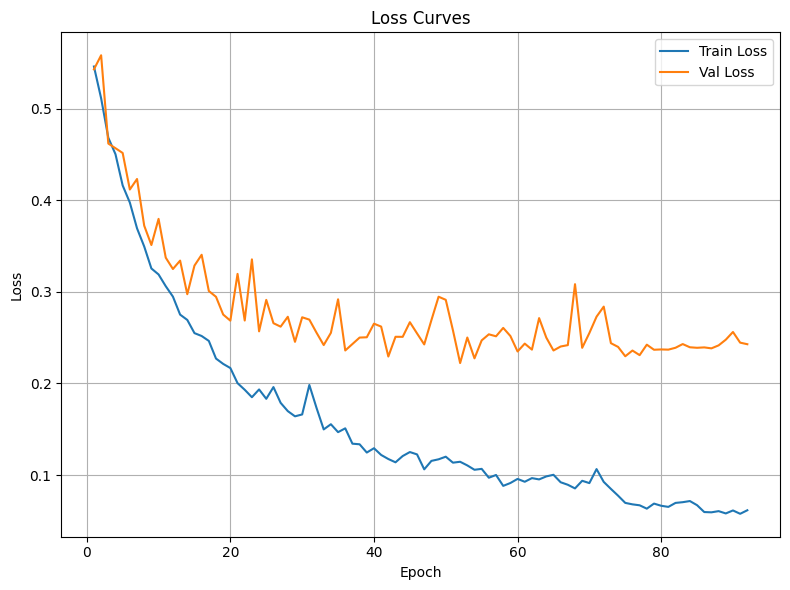

Saved: results/loss_curve.png


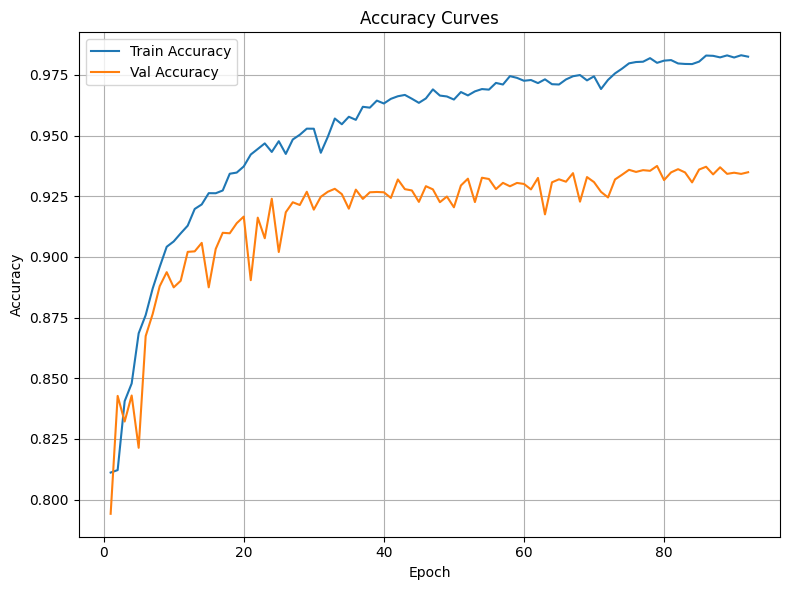

Saved: results/accuracy_curve.png


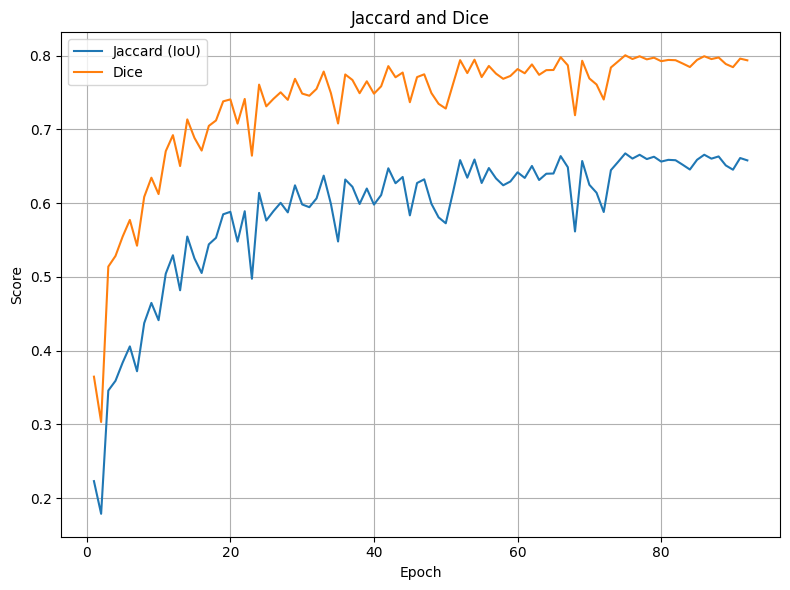

Saved: results/jaccard_dice_curve.png


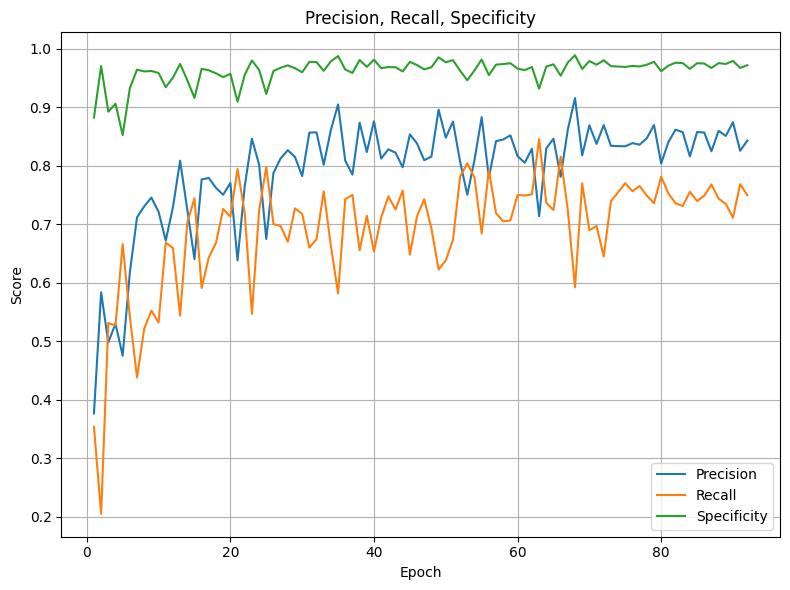

Saved: results/precision_recall_specificity.png


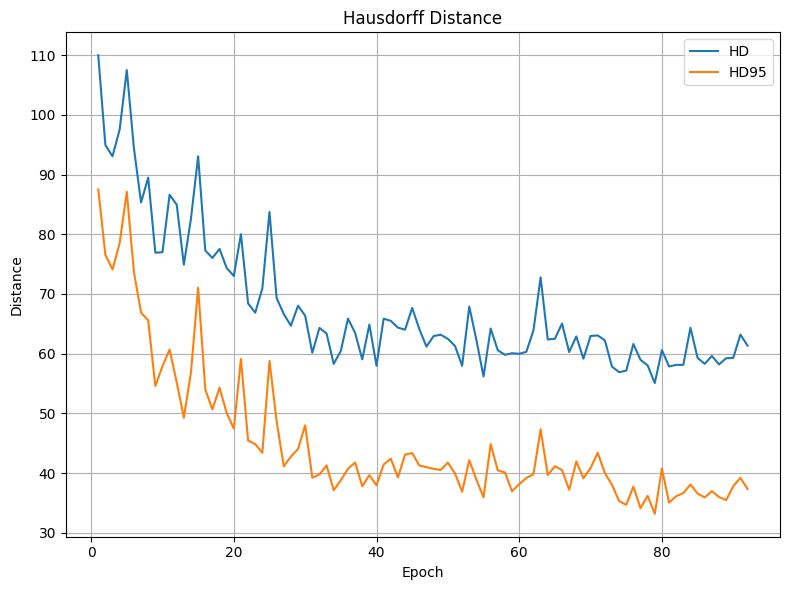

Saved: results/hausdorff_curve.png


In [33]:
def plot_individual_curves(history):
    os.makedirs("results", exist_ok=True)
    epochs = history.get('epoch', [])
    if len(epochs) == 0:
        print("No epoch data found in history. Nothing to plot.")
        return

    # Loss - try both possible keys
    train_loss = history.get('train_loss', [])
    val_loss = history.get('val_loss', history.get('loss', []))  # fallback to 'loss' if 'val_loss' missing

    if len(train_loss) == len(epochs) and len(val_loss) == len(epochs):
        plt.figure(figsize=(8,6))
        plt.plot(epochs, train_loss, label='Train Loss')
        plt.plot(epochs, val_loss, label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss Curves')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('results/loss_curve.png', dpi=150)
        plt.show()
        print("Saved: results/loss_curve.png")
    else:
        print("Skipping loss plot – data length mismatch or missing.")

    # Accuracy
    train_acc = history.get('train_accuracy', [])
    val_acc = history.get('val_accuracy', [])
    if len(train_acc) == len(epochs) and len(val_acc) == len(epochs):
        plt.figure(figsize=(8,6))
        plt.plot(epochs, train_acc, label='Train Accuracy')
        plt.plot(epochs, val_acc, label='Val Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Accuracy Curves')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('results/accuracy_curve.png', dpi=150)
        plt.show()
        print("Saved: results/accuracy_curve.png")
    else:
        print("Skipping accuracy plot – data missing.")

    # Jaccard & Dice
    jaccard = history.get('jaccard', [])
    dice = history.get('dice', [])
    if len(jaccard) == len(epochs) and len(dice) == len(epochs):
        plt.figure(figsize=(8,6))
        plt.plot(epochs, jaccard, label='Jaccard (IoU)')
        plt.plot(epochs, dice, label='Dice')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.title('Jaccard and Dice')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('results/jaccard_dice_curve.png', dpi=150)
        plt.show()
        print("Saved: results/jaccard_dice_curve.png")
    else:
        print("Skipping Jaccard/Dice plot – data missing.")

    # Precision/Recall/Specificity
    precision = history.get('precision', [])
    recall = history.get('recall', [])
    specificity = history.get('specificity', [])
    if all(len(x) == len(epochs) for x in [precision, recall, specificity]):
        plt.figure(figsize=(8,6))
        plt.plot(epochs, precision, label='Precision')
        plt.plot(epochs, recall, label='Recall')
        plt.plot(epochs, specificity, label='Specificity')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.title('Precision, Recall, Specificity')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('results/precision_recall_specificity.png', dpi=150)
        plt.show()
        print("Saved: results/precision_recall_specificity.png")
    else:
        print("Skipping precision/recall/specificity plot – data missing.")

    # Hausdorff
    hd_mean = history.get('hd_mean', [])
    hd95_mean = history.get('hd95_mean', [])
    if len(hd_mean) == len(epochs) and len(hd95_mean) == len(epochs):
        plt.figure(figsize=(8,6))
        plt.plot(epochs, hd_mean, label='HD')
        plt.plot(epochs, hd95_mean, label='HD95')
        plt.xlabel('Epoch')
        plt.ylabel('Distance')
        plt.title('Hausdorff Distance')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('results/hausdorff_curve.png', dpi=150)
        plt.show()
        print("Saved: results/hausdorff_curve.png")
    else:
        print("Skipping Hausdorff plot – data missing.")

plot_individual_curves(history)

In [34]:
# Load best model
model.load_state_dict(torch.load('/content/models/best_vmunet.pth'))
model.eval()

# Reset metrics
jaccard.reset()
dice.reset()
accuracy.reset()
precision.reset()
recall.reset()
specificity.reset()
hd_list = []
hd95_list = []
test_loss_total = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)                    # already probabilities (0..1)
        loss = criterion(outputs, masks)
        test_loss_total += loss.item()

        # === FIXED: no extra sigmoid ===
        preds = (outputs > 0.5).squeeze(1).long()

        jaccard.update(preds, masks)
        dice.update(preds, masks)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        specificity.update(preds, masks)

        for i in range(images.size(0)):
            pred_np = preds[i].cpu().numpy()
            mask_np = masks[i].cpu().numpy()
            hd, hd95 = compute_hausdorff(pred_np, mask_np)
            hd_list.append(hd)
            hd95_list.append(hd95)

avg_test_loss = test_loss_total / len(test_loader)

# Final metrics
jaccard_score = jaccard.compute().cpu().item()
dice_score = dice.compute().cpu().item()
acc_score = accuracy.compute().cpu().item()
prec_score = precision.compute().cpu().item()
rec_score = recall.compute().cpu().item()
spec_score = specificity.compute().cpu().item()
hd_mean = np.nanmean(hd_list)
hd95_mean = np.nanmean(hd95_list)

print("\n===== Test Set Results =====")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Accuracy: {acc_score:.4f}")
print(f"Jaccard: {jaccard_score:.4f}")
print(f"Dice: {dice_score:.4f}")
print(f"Precision: {prec_score:.4f}")
print(f"Recall: {rec_score:.4f}")
print(f"Specificity: {spec_score:.4f}")
print(f"HD: {hd_mean:.2f}")
print(f"HD95: {hd95_mean:.2f}")

# Save test results
test_results = pd.DataFrame([{
    'loss': avg_test_loss,
    'accuracy': acc_score,
    'jaccard': jaccard_score,
    'dice': dice_score,
    'precision': prec_score,
    'recall': rec_score,
    'specificity': spec_score,
    'hd': hd_mean,
    'hd95': hd95_mean
}])
test_results.to_csv('results/test_metrics.csv', index=False)
print("Test metrics saved to results/test_metrics.csv")

Testing: 100%|██████████| 19/19 [00:08<00:00,  2.35it/s]



===== Test Set Results =====
Test Loss: 0.2177
Accuracy: 0.9365
Jaccard: 0.6681
Dice: 0.8011
Precision: 0.8290
Recall: 0.7749
Specificity: 0.9684
HD: 54.21
HD95: 34.93
Test metrics saved to results/test_metrics.csv


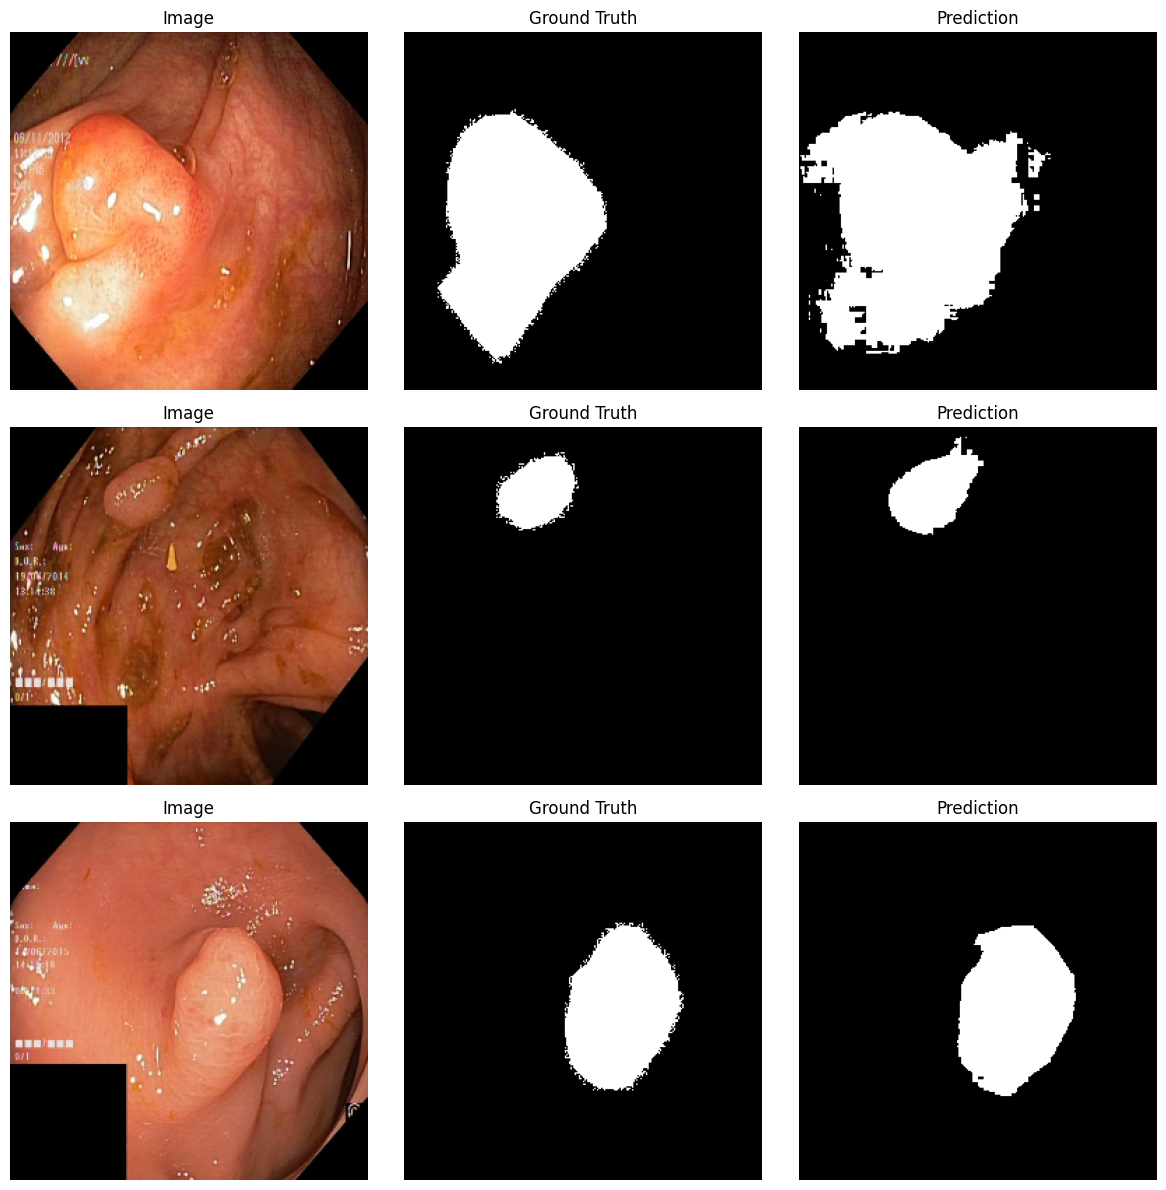

In [39]:
def visualize_test_predictions(model, dataset, num_samples=3):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*4))
    indices = random.sample(range(len(dataset)), num_samples)

    for row, idx in enumerate(indices):
        img, mask = dataset[idx]
        img_tensor = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_tensor)                         # already probabilities
            pred = (output > 0.5).squeeze().cpu().numpy().astype(np.uint8)  # no extra sigmoid

        # Denormalize image
        img_np = img.permute(1,2,0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)

        mask_np = mask.cpu().numpy()

        axes[row,0].imshow(img_np)
        axes[row,0].set_title('Image')
        axes[row,0].axis('off')

        axes[row,1].imshow(mask_np, cmap='gray')
        axes[row,1].set_title('Ground Truth')
        axes[row,1].axis('off')

        axes[row,2].imshow(pred, cmap='gray')
        axes[row,2].set_title('Prediction')
        axes[row,2].axis('off')

    plt.tight_layout()
    plt.savefig('results/test_predictions.png', dpi=150)
    plt.show()

# Call the function
visualize_test_predictions(model, test_dataset, num_samples=3)

In [41]:
# Replace with your repo URL
remote_url = "git@github.com:Amir-Rouhbakhsh/mamba-models.git"

!git remote add origin {remote_url}

# Use a personal access token for authentication
# You will be prompted for username and password (use token as password)
!git push -u origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
